# Notebook 01 — Tokenization & Embeddings

**Goal:** Understand how raw text is converted into vectors that a neural network can process.

We'll build the *input pipeline* of a transformer from scratch:

```
raw text
   │
   ▼  tiktoken (BPE tokenizer)
integer token IDs   [batch, seq_len]
   │
   ▼  nn.Embedding  (learnable lookup table)
token embeddings    [batch, seq_len, d_model]
   │
   ▼  + sinusoidal positional encoding
input to transformer  [batch, seq_len, d_model]
```

---

### Contents
1. [Tokenization with tiktoken](#1)
2. [Vocabulary & token statistics](#2)
3. [Token embeddings — nn.Embedding](#3)
4. [Sinusoidal positional encoding](#4)
5. [Combining embeddings + PE](#5)
6. [Visualising the embedding space (PCA)](#6)
7. [Key takeaways](#7)

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys, math
import tiktoken                    # OpenAI BPE tokenizer library
import torch                       # PyTorch — tensors, autograd, nn
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.decomposition import PCA
from collections import Counter

# Add project root to path so we can import utils
sys.path.insert(0, '..')

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('=' * 60)
print('  Notebook 01 — Tokenization & Embeddings')
print('=' * 60)
print(f'  PyTorch  : {torch.__version__}')
print(f'  tiktoken : {tiktoken.__version__}')
print('=' * 60)

  Notebook 01 — Tokenization & Embeddings
  PyTorch  : 2.11.0
  tiktoken : 0.12.0


<a id='1'></a>
## 1 — Tokenization with tiktoken

A neural network can only process numbers, never raw text.  
**Tokenization** converts a string into a sequence of integer IDs.

GPT-2 (and GPT-3/4) use **Byte-Pair Encoding (BPE)**:

1. Start with a vocabulary of all 256 raw bytes.
2. Repeatedly merge the *most frequent* pair of adjacent symbols into a new token.
3. Repeat until the target vocabulary size is reached (GPT-2 uses **50 257** tokens).

The result: common words are single tokens (`" the"` → `262`), rare words are  
split into sub-word pieces (`"transformer"` → `[83, 26084]` or similar).

This is important because it gives the model a *finite, manageable vocabulary*  
while still being able to represent any UTF-8 text.

In [3]:
# ── Load the GPT-2 tokenizer ──────────────────────────────────────────────────
# 'gpt2' encoding uses 50 257 tokens and the same vocab/merge rules as GPT-2.
enc = tiktoken.get_encoding('gpt2')

VOCAB_SIZE = enc.n_vocab   # 50 257

print(f'Vocabulary size: {VOCAB_SIZE:,} tokens')
print()

# ── Encode a sentence ────────────────────────────────────────────────────────
sentence = "The transformer architecture revolutionised natural language processing."
token_ids = enc.encode(sentence)     # list[int]  — the token IDs
tokens    = [enc.decode([t]) for t in token_ids]  # human-readable pieces

print('Input text:')
print(f'  "{sentence}"')
print()
print('Token IDs:')
print(f'  {token_ids}')
print()
print('Human-readable pieces (each piece → its ID):')
print('-' * 50)
for i, (tok, tid) in enumerate(zip(tokens, token_ids)):
    # repr() shows spaces explicitly (e.g. ' The' vs 'The')
    print(f'  [{i:2d}]  {repr(tok):20s}  →  {tid}')
print('-' * 50)
print(f'  {len(token_ids)} tokens for {len(sentence)} characters')
print(f'  Compression ratio: {len(sentence)/len(token_ids):.1f} chars/token')

Vocabulary size: 50,257 tokens

Input text:
  "The transformer architecture revolutionised natural language processing."

Token IDs:
  [464, 47385, 10959, 5854, 1417, 3288, 3303, 7587, 13]

Human-readable pieces (each piece → its ID):
--------------------------------------------------
  [ 0]  'The'                 →  464
  [ 1]  ' transformer'        →  47385
  [ 2]  ' architecture'       →  10959
  [ 3]  ' revolution'         →  5854
  [ 4]  'ised'                →  1417
  [ 5]  ' natural'            →  3288
  [ 6]  ' language'           →  3303
  [ 7]  ' processing'         →  7587
  [ 8]  '.'                   →  13
--------------------------------------------------
  9 tokens for 72 characters
  Compression ratio: 8.0 chars/token


In [4]:
# ── Decode back to text ───────────────────────────────────────────────────────
# enc.decode takes a list of ints and returns the original string.
reconstructed = enc.decode(token_ids)

print('Decoded back to text:')
print(f'  "{reconstructed}"')
print()
print(f'  Round-trip match: {reconstructed == sentence}')
print()

# ── A few interesting individual tokens ──────────────────────────────────────
interesting = ['Hello', ' world', '!', '\n', ' transformer', ' Python', '123']
print('Some individual token encodings:')
print('-' * 40)
for word in interesting:
    ids = enc.encode(word)
    print(f'  {repr(word):20s}  →  {ids}')
print('-' * 40)
print()
print('KEY INSIGHT: Note that " world" (with a leading space) is ONE token,')
print('but "world" (without space) might tokenize differently. BPE encodes')
print('spacing as part of the token — this is a quirk of GPT-2 tokenization.')

Decoded back to text:
  "The transformer architecture revolutionised natural language processing."

  Round-trip match: True

Some individual token encodings:
----------------------------------------
  'Hello'               →  [15496]
  ' world'              →  [995]
  '!'                   →  [0]
  '\n'                  →  [198]
  ' transformer'        →  [47385]
  ' Python'             →  [11361]
  '123'                 →  [10163]
----------------------------------------

KEY INSIGHT: Note that " world" (with a leading space) is ONE token,
but "world" (without space) might tokenize differently. BPE encodes
spacing as part of the token — this is a quirk of GPT-2 tokenization.


<a id='2'></a>
## 2 — Vocabulary & Token Statistics

Let's encode a larger piece of text and look at which tokens are most common.

In [5]:
# ── A short corpus to analyse ─────────────────────────────────────────────────
corpus = """
Attention mechanisms have become an integral part of compelling sequence modelling
and transduction models in various tasks, allowing modelling of dependencies without
regard to their distance in the input or output sequences. In all but a few cases,
such attention mechanisms are used in conjunction with a recurrent network.

We propose a new simple network architecture, the Transformer, based solely on
attention mechanisms, dispensing with recurrence and convolutions entirely.
Experiments on two machine translation tasks show these models to be superior in
quality while being more parallelizable and requiring significantly less time to train.

The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder.
"""

corpus_ids = enc.encode(corpus)
print(f'Corpus: {len(corpus)} chars → {len(corpus_ids)} tokens')
print(f'Average: {len(corpus)/len(corpus_ids):.2f} chars/token')
print()

# ── Most common tokens ────────────────────────────────────────────────────────
counter = Counter(corpus_ids)
top_n = 15
print(f'Top {top_n} most frequent tokens in corpus:')
print(f'{"ID":>8}  {"Token":>20}  {"Count":>6}')
print('-' * 40)
for token_id, count in counter.most_common(top_n):
    decoded = repr(enc.decode([token_id]))
    print(f'{token_id:>8}  {decoded:>20}  {count:>6}')
print('-' * 40)

Corpus: 799 chars → 153 tokens
Average: 5.22 chars/token

Top 15 most frequent tokens in corpus:
      ID                 Token   Count
----------------------------------------
     198                  '\n'      13
      11                   ','       5
      13                   '.'       5
     287                 ' in'       4
     257                  ' a'       4
   11701         ' mechanisms'       3
    4981             ' models'       3
     284                 ' to'       3
     319                 ' on'       3
     290                ' and'       3
    1463              'ention'       2
     281                 ' an'       2
     286                 ' of'       2
    8379           ' sequence'       2
   38591          ' modelling'       2
----------------------------------------


<a id='3'></a>
## 3 — Token Embeddings: `nn.Embedding`

After tokenization we have integer IDs. But an integer has no geometric meaning —  
`token 42` is not "twice" `token 21`. We need to map each integer to a continuous  
vector in $\mathbb{R}^{d_{\text{model}}}$.

**`nn.Embedding(vocab_size, d_model)`** is simply a *learnable lookup table*:

$$
E \in \mathbb{R}^{\text{vocab\_size} \times d_{\text{model}}}
\qquad
\text{embed}(\text{id}) = E[\text{id}]
$$

During training, the rows of $E$ are updated by gradient descent so that tokens  
with similar roles end up with similar vectors (nearby in embedding space).

**Key properties:**
- Lookup is $O(1)$ — just an array index.
- Each row is a vector of `d_model` floats — the "meaning" of that token.
- The embedding is *shared* with the final output layer (weight tying).

In our GPT model, we also **scale** the embedding by $\sqrt{d_{\text{model}}}$  
to keep the magnitude consistent with the positional encoding that's added next.

In [6]:
# ── Build a small embedding layer ─────────────────────────────────────────────
D_MODEL = 64        # embedding dimension (same as our GPT config)

# nn.Embedding is a matrix of shape [vocab_size, d_model]
# Initialised from N(0, 1) by default
embedding = nn.Embedding(
    num_embeddings = VOCAB_SIZE,   # number of distinct token IDs
    embedding_dim  = D_MODEL,      # size of each embedding vector
)

print('Embedding layer:')
print(f'  Weight matrix shape: {list(embedding.weight.shape)}')
print(f'  Parameters:          {embedding.weight.numel():,}')
print(f'  Memory:              {embedding.weight.numel() * 4 / 1024:.1f} KB (float32)')
print()

# ── Embed the tokens from our sentence ───────────────────────────────────────
ids_tensor = torch.tensor(token_ids).unsqueeze(0)   # shape: [1, seq_len]
# [batch=1, seq_len]

raw_embeddings = embedding(ids_tensor)   # shape: [1, seq_len, d_model]
# Indexing: embedding(x) is equivalent to embedding.weight[x]

# Scale by sqrt(d_model) — standard GPT practice
scale          = math.sqrt(D_MODEL)         # ≈ 8.0
scaled_embeddings = raw_embeddings * scale  # [1, seq_len, d_model]

print('Token IDs tensor shape:', list(ids_tensor.shape))           # [1, seq_len]
print('Raw embeddings shape  :', list(raw_embeddings.shape))       # [1, seq_len, d_model]
print('Scaled embeddings shape:', list(scaled_embeddings.shape))   # [1, seq_len, d_model]
print()
print('First token embedding (raw, first 8 dims):')
print('  ', raw_embeddings[0, 0, :8].detach().numpy().round(4))
print(f'  Norm (raw):    {raw_embeddings[0,0].norm().item():.4f}')
print(f'  Norm (scaled): {scaled_embeddings[0,0].norm().item():.4f}')

Embedding layer:
  Weight matrix shape: [50257, 64]
  Parameters:          3,216,448
  Memory:              12564.2 KB (float32)

Token IDs tensor shape: [1, 9]
Raw embeddings shape  : [1, 9, 64]
Scaled embeddings shape: [1, 9, 64]

First token embedding (raw, first 8 dims):
   [ 0.0917  2.0205  0.1794 -0.664   1.6553 -2.1122 -1.3458 -0.0335]
  Norm (raw):    8.2132
  Norm (scaled): 65.7054


<a id='4'></a>
## 4 — Sinusoidal Positional Encoding

**The problem:** Attention treats its inputs as a *set* — it has no inherent sense  
of position. The word "cat" at position 3 looks identical to "cat" at position 10.

**The solution:** Add a *position-specific signal* to each token embedding.

The original paper ("Attention is All You Need") uses **sinusoidal functions**:

$$
PE_{(pos,\, 2i)}   = \sin\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)
\qquad
PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)
$$

where $pos$ is the position in the sequence and $i$ is the dimension index.

**Why sinusoids?**
- They have a fixed, known range $[-1, 1]$ regardless of sequence length.
- The relative position $PE_{pos+k}$ is a linear function of $PE_{pos}$ — so the  
  model can learn to attend to *relative* offsets.
- No parameters to learn — the encoding is deterministic and can extrapolate  
  to sequences longer than those seen during training.
- Different dimensions oscillate at different frequencies, like a multi-scale clock.

In [7]:
# ── Build sinusoidal PE from scratch ──────────────────────────────────────────
def build_sinusoidal_pe(max_seq_len: int, d_model: int) -> torch.Tensor:
    """Return positional encoding table of shape [max_seq_len, d_model]."""
    # position indices: [0, 1, 2, ..., max_seq_len-1]
    position = torch.arange(max_seq_len).unsqueeze(1).float()  # [max_seq_len, 1]

    # dimension indices: [0, 2, 4, ..., d_model-2]  (even dimensions only)
    # div_term[i] = 1 / (10000^(2i/d_model))
    # We compute in log space for numerical stability:
    #   10000^(2i/d_model) = exp(2i/d_model * log(10000))
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float()   # [d_model/2]  — 0, 2, 4 ...
        * -(math.log(10000.0) / d_model)       # × -log(10000)/d_model
    )  # shape: [d_model/2]

    pe = torch.zeros(max_seq_len, d_model)   # [max_seq_len, d_model]

    # Even dimensions get sine, odd dimensions get cosine
    pe[:, 0::2] = torch.sin(position * div_term)   # [max_seq_len, d_model/2]
    pe[:, 1::2] = torch.cos(position * div_term)   # [max_seq_len, d_model/2]

    return pe


MAX_SEQ = 128
pe_table = build_sinusoidal_pe(MAX_SEQ, D_MODEL)   # [128, 64]

print('Positional encoding table shape:', list(pe_table.shape))
print(f'Value range: [{pe_table.min().item():.4f}, {pe_table.max().item():.4f}]')
print()
print('First 5 positions, first 8 dimensions:')
print('-' * 55)
for pos in range(5):
    row = pe_table[pos, :8].numpy().round(4)
    print(f'  pos {pos}: {row}')
print('-' * 55)
print()
print('Note: pos=0 always has PE = [0, 1, 0, 1, ...]')
print('(sin(0)=0, cos(0)=1 for all frequencies)')

Positional encoding table shape: [128, 64]
Value range: [-1.0000, 1.0000]

First 5 positions, first 8 dimensions:
-------------------------------------------------------
  pos 0: [0. 1. 0. 1. 0. 1. 0. 1.]
  pos 1: [0.8415 0.5403 0.6816 0.7318 0.5332 0.846  0.4093 0.9124]
  pos 2: [ 0.9093 -0.4161  0.9975  0.0709  0.9021  0.4315  0.7469  0.6649]
  pos 3: [ 0.1411 -0.99    0.7783 -0.6279  0.9933 -0.116   0.9536  0.301 ]
  pos 4: [-0.7568 -0.6536  0.1415 -0.9899  0.7785 -0.6277  0.9933 -0.1157]
-------------------------------------------------------

Note: pos=0 always has PE = [0, 1, 0, 1, ...]
(sin(0)=0, cos(0)=1 for all frequencies)


<a id='5'></a>
## 5 — Combining Token Embeddings + Positional Encoding

The final input to the transformer is simply the **sum**:

$$
\mathbf{x}_{pos} = \sqrt{d_{\text{model}}} \cdot E[\text{token\_id}_{pos}] + PE_{pos}
$$

Both components live in the same $\mathbb{R}^{d_{\text{model}}}$ space, so addition  
makes sense geometrically. The $\sqrt{d_{\text{model}}}$ scale on the embedding  
ensures it isn't swamped by the PE (which has magnitude ~1).

In [9]:
# ── Combine embeddings + PE (same way our GPTModel does it) ───────────────────
seq_len = ids_tensor.shape[1]   # number of tokens in our sentence

# 1. Token embedding, scaled
token_emb = embedding(ids_tensor) * math.sqrt(D_MODEL)  # [1, seq_len, d_model]

# 2. Positional encoding for positions 0..seq_len-1
#    We add a batch dimension so shapes broadcast: [1, seq_len, d_model]
pe_slice = pe_table[:seq_len].unsqueeze(0)              # [1, seq_len, d_model]

# 3. Add them together
transformer_input = token_emb + pe_slice                # [1, seq_len, d_model]

print('Shape summary:')
print(f'  Token IDs              : {list(ids_tensor.shape)}  = [batch, seq_len]')
print(f'  Token embedding (scaled): {list(token_emb.shape)}  = [batch, seq_len, d_model]')
print(f'  Positional encoding     : {list(pe_slice.shape)}  = [batch, seq_len, d_model]')
print(f'  Transformer input       : {list(transformer_input.shape)}  = [batch, seq_len, d_model]')
print()

# ── Compare magnitudes ────────────────────────────────────────────────────────
print('L2 norms (per position, first 5 positions):')
print(f'{"pos":>5}  {"token_emb":>12}  {"PE":>12}  {"combined":>12}')
print('-' * 50)
for i in range(min(5, seq_len)):
    n_tok = token_emb[0, i].norm().item()
    n_pe  = pe_slice[0, i].norm().item()
    n_comb= transformer_input[0, i].norm().item()
    print(f'{i:>5}  {n_tok:>12.4f}  {n_pe:>12.4f}  {n_comb:>12.4f}')
print('-' * 50)
print()
print(f'Expected PE norm ≈ sqrt({D_MODEL}/2) = {math.sqrt(D_MODEL/2):.3f}')
print('(each sin/cos pair contributes ~1, so sum of squares ≈ d_model/2)')

Shape summary:
  Token IDs              : [1, 9]  = [batch, seq_len]
  Token embedding (scaled): [1, 9, 64]  = [batch, seq_len, d_model]
  Positional encoding     : [1, 9, 64]  = [batch, seq_len, d_model]
  Transformer input       : [1, 9, 64]  = [batch, seq_len, d_model]

L2 norms (per position, first 5 positions):
  pos     token_emb            PE      combined
--------------------------------------------------
    0       65.7054        5.6569       65.0293
    1       67.7776        5.6569       68.5869
    2       68.5572        5.6569       68.2887
    3       61.3033        5.6569       60.8874
    4       59.1863        5.6569       59.1330
--------------------------------------------------

Expected PE norm ≈ sqrt(64/2) = 5.657
(each sin/cos pair contributes ~1, so sum of squares ≈ d_model/2)


<a id='6'></a>
## 6 — Visualising the Embedding Space (PCA)

After training, the embedding matrix organises tokens by meaning.  
To see this, we can project the high-dimensional embeddings down to 2D  
using **Principal Component Analysis (PCA)**.

Since our embeddings are *random* (not trained yet), the plot will look  
like noise — but we'll use it to understand the machinery. Notebook 05  
trains the model and notebook 06 shows the structure that emerges.

We also look at the geometry of some hand-picked tokens to understand  
what the embeddings *will* learn to encode.

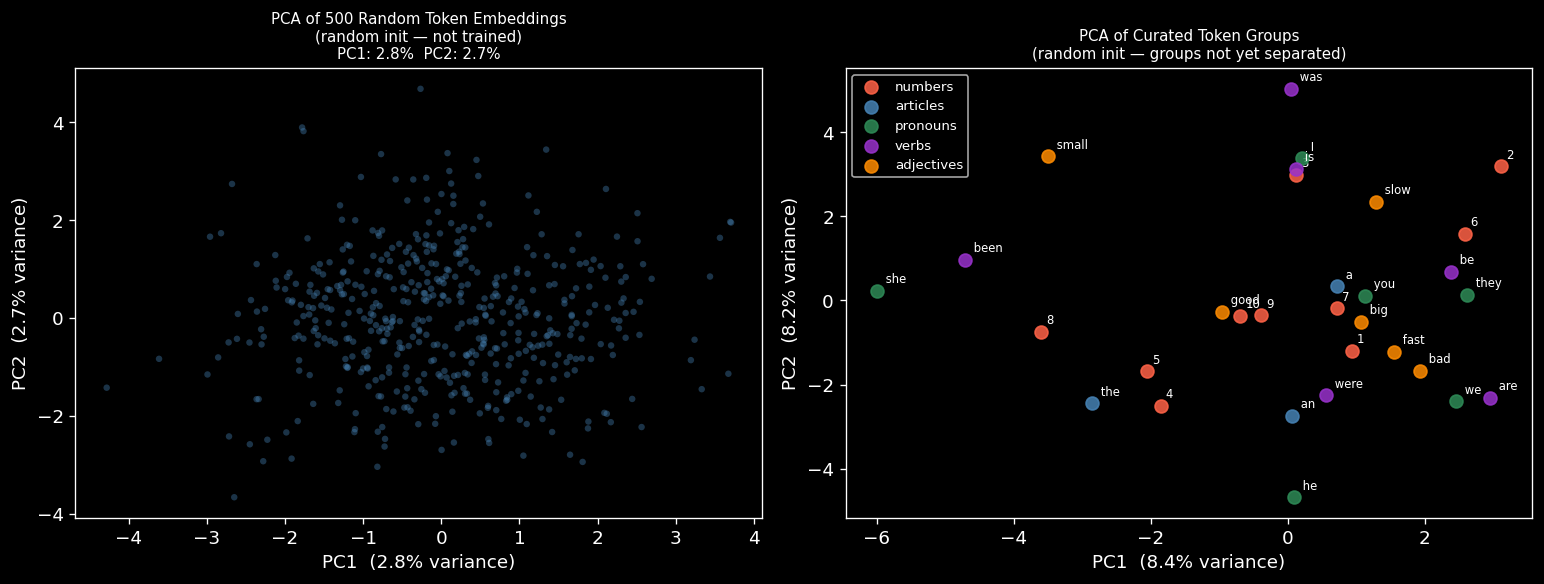


KEY INSIGHT: Before training the token groups are scrambled.
After training (notebook 05+06), similar words cluster together.


In [11]:
# ── PCA of the full embedding matrix ─────────────────────────────────────────
# We only have d_model=64 and VOCAB_SIZE=50257.
# For speed we sample 500 random token IDs.
rng = np.random.default_rng(42)
sample_ids = rng.choice(VOCAB_SIZE, size=500, replace=False)

sample_emb = embedding.weight[sample_ids].detach().numpy()   # [500, 64]

pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(sample_emb)   # [500, 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter of 500 random tokens (just dots, no labels for clarity)
axes[0].scatter(coords_2d[:, 0], coords_2d[:, 1],
                alpha=0.4, s=15, c='steelblue', edgecolors='none')
axes[0].set_title(f'PCA of 500 Random Token Embeddings\n'
                  f'(random init — not trained)\n'
                  f'PC1: {pca.explained_variance_ratio_[0]:.1%}  '
                  f'PC2: {pca.explained_variance_ratio_[1]:.1%}', fontsize=9)
axes[0].set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]:.1%} variance)')

# Right: PCA of a curated set of semantically related tokens
token_groups = {
    'numbers':   ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10'],
    'articles':  [' the', ' a', ' an'],
    'pronouns':  [' I', ' you', ' he', ' she', ' we', ' they'],
    'verbs':     [' is', ' are', ' was', ' were', ' be', ' been'],
    'adjectives':[' good', ' bad', ' big', ' small', ' fast', ' slow'],
}
colors_for_groups = ['tomato', 'steelblue', 'seagreen', 'darkorchid', 'darkorange']

all_words, all_vecs, all_colors, all_groups = [], [], [], []
for (group, words), color in zip(token_groups.items(), colors_for_groups):
    for word in words:
        ids_w = enc.encode(word)   # may be multiple tokens
        if len(ids_w) == 1:        # only single-token words for clarity
            vec = embedding.weight[ids_w[0]].detach().numpy()
            all_words.append(word)
            all_vecs.append(vec)
            all_colors.append(color)
            all_groups.append(group)

all_vecs_np = np.array(all_vecs)  # [n_words, d_model]
pca2 = PCA(n_components=2, random_state=42)
coords2 = pca2.fit_transform(all_vecs_np)  # [n_words, 2]

# Plot with labels
plotted_groups = set()
for i, (word, color, group) in enumerate(zip(all_words, all_colors, all_groups)):
    label = group if group not in plotted_groups else None
    axes[1].scatter(coords2[i, 0], coords2[i, 1],
                    c=color, s=60, alpha=0.85, label=label, zorder=3)
    axes[1].annotate(word, (coords2[i, 0], coords2[i, 1]),
                     fontsize=7, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')
    plotted_groups.add(group)

axes[1].legend(loc='upper left', fontsize=8, framealpha=0.8)
axes[1].set_title('PCA of Curated Token Groups\n(random init — groups not yet separated)',
                  fontsize=9)
axes[1].set_xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]:.1%} variance)')

plt.tight_layout()
plt.show()
print()
print('KEY INSIGHT: Before training the token groups are scrambled.')
print('After training (notebook 05+06), similar words cluster together.')

In [12]:
# ── Cosine similarity: a glimpse of semantic structure (before training) ───────
def cosine_similarity(v1: torch.Tensor, v2: torch.Tensor) -> float:
    """Cosine similarity between two vectors."""
    return (v1 @ v2 / (v1.norm() * v2.norm())).item()

def get_vec(word: str) -> torch.Tensor:
    ids = enc.encode(word)
    return embedding.weight[ids[0]].detach()

pairs = [
    (' cat',   ' dog'),
    (' cat',   ' car'),
    (' king',  ' queen'),
    (' good',  ' bad'),
    (' good',  ' great'),
    (' Paris', ' London'),
]

print('Cosine similarities (random init — should be near 0):')
print(f'{"Word 1":>12}  {"Word 2":>12}  {"CosSim":>8}')
print('-' * 40)
for w1, w2 in pairs:
    sim = cosine_similarity(get_vec(w1), get_vec(w2))
    print(f'{repr(w1):>12}  {repr(w2):>12}  {sim:>8.4f}')
print('-' * 40)
print()
print('After training, you would expect similar words (cat/dog, good/great)')
print('to have higher cosine similarity than dissimilar ones (cat/car).')

Cosine similarities (random init — should be near 0):
      Word 1        Word 2    CosSim
----------------------------------------
      ' cat'        ' dog'    0.1382
      ' cat'        ' car'   -0.0346
     ' king'      ' queen'   -0.1455
     ' good'        ' bad'    0.2019
     ' good'      ' great'    0.0524
    ' Paris'     ' London'    0.0958
----------------------------------------

After training, you would expect similar words (cat/dog, good/great)
to have higher cosine similarity than dissimilar ones (cat/car).


<a id='7'></a>
## 7 — Key Takeaways

```
╔══════════════════════════════════════════════════════════════╗
║  KEY TAKEAWAYS — Tokenization & Embeddings                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. BPE tokenization balances vocabulary size vs. coverage.  ║
║     GPT-2 uses 50 257 tokens to represent any Unicode text.  ║
║                                                              ║
║  2. nn.Embedding is just a matrix — token_id indexes a row.  ║
║     The rows are learned during training via backprop.       ║
║                                                              ║
║  3. Positional encoding injects position info additively.    ║
║     Sinusoids are deterministic, range-bounded, and allow    ║
║     the model to reason about relative positions.            ║
║                                                              ║
║  4. The transformer input is:                               ║
║       x = √d_model · Embedding(token_id) + PE(position)    ║
║                                                              ║
║  5. Shape to remember:                                       ║
║       [batch, seq_len] → [batch, seq_len, d_model]          ║
║       This is the shape that flows through every layer.      ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
```

**Next up:** Notebook 02 builds the attention mechanism — the heart of the transformer.

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────────
print('=' * 60)
print('  Notebook 01 — Summary')
print('=' * 60)
print(f'  Tokenizer      : tiktoken gpt2  ({VOCAB_SIZE:,} tokens)')
print(f'  d_model        : {D_MODEL}')
print(f'  max_seq_len    : {MAX_SEQ}')
print(f'  Embedding params: {VOCAB_SIZE * D_MODEL:,}')
print(f'  PE params       : 0  (no learnable params)')
print()
print('  Input pipeline: text → token IDs → embeddings → + PE → transformer')
print('=' * 60)